In [ ]:
import collections
import copy
import itertools
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.notebook import tqdm

random.seed(1234)
np.random.seed(1234)
torch.manual_seed(1234)
print("numpy: ", np.__version__)
print("torch: ", torch.__version__)

numpy:  2.0.2
torch:  2.9.0+cpu


### 環境(シミュレータ)

In [ ]:
class PriceEnvironment():
    def __init__(self, max_inventory, max_step_count, price_min, price_max):
        self.max_inventory = max_inventory
        self.inventory = self.max_inventory
        self.max_step_count = max_step_count
        self.step_count = 0
        self.price_min = price_min
        self.price_max = price_max

    def step(self, continuous_action):
        price = self.price_min + (self.price_max - self.price_min) * ((continuous_action + 1) / 2)  # price_min～price_maxでの連続値 # continuous_actionはtanhの結果で-1～1の想定
        price = round(number=price,  # 1の桁を四捨五入して連続値のpriceを10刻みに量子化する
                      ndigits=-1)
        price = np.clip(a=price,  # 1の桁の四捨五入でprice_minを下回ったり、price_maxを上回ったりする事を考慮してnp.clipで範囲内の収める
                        a_min=self.price_min,
                        a_max=self.price_max)
        demand_expectation = int((self.price_max / price) * (self.inventory * 0.05))  # 「在庫の5%」×「重み」を「需要の期待値」とする # 「重み」は、最高価格に対する価格の割合の逆数(価格が高いと重みは小さい)とする
        demand = np.random.poisson(lam=demand_expectation,  # 「需要の期待値」を「ポアソン分布の期待値」として、ポアソン分布から「需要」を確率的に得る
                                   size=None)  # 引数sizeをNoneにする事でポアソン分布から1個だけの値を確率的に得る # sizeを100にすると100個の値を確率的に得る形になる
        saled_inventory = min(self.inventory, max(demand, 0))  # 「売れた在庫」は、「需要」と「在庫数」の小さい方の値とする # 「在庫数」以上の「需要」は売れないため
        reward = price * saled_inventory
        self.inventory = self.inventory - saled_inventory
        inventory_ratio = self.inventory / self.max_inventory
        self.step_count = self.step_count + 1
        step_ratio = (self.max_step_count - self.step_count) / self.max_step_count
        if self.inventory <= 0 or self.step_count >= self.max_step_count:
            done = True
        else:
            done = False
        next_state = np.array([inventory_ratio, step_ratio],
                              dtype=np.float32)
        return reward, next_state, done

    def reset(self):
        self.inventory = self.max_inventory
        self.step_count = 0
        initial_inventory_ratio = self.inventory / self.max_inventory
        initial_step_ratio = (self.max_step_count - self.step_count) / self.max_step_count
        initial_state = np.array([initial_inventory_ratio, initial_step_ratio],
                                 dtype=np.float32)
        done = False
        return initial_state, done

### 時系列経験バッファ

In [ ]:
class SequenceReplayBuffer():
    def __init__(self, max_queue_size):
        self.seq_replay_buffer = collections.deque(maxlen=max_queue_size)

    def __len__(self):
        return len(self.seq_replay_buffer)

    def add_data(self, state, action, reward, next_state, done):
        datas = (state, action, reward, next_state, done)
        self.seq_replay_buffer.append(datas)  # タプルを1要素としてリプレイバッファに保存する

    def get_batch_data(self, batch_size, seq_size):
        batch_state_list = []
        batch_action_list = []
        batch_reward_list = []
        batch_next_state_list = []
        batch_done_list = []
        for _ in range(batch_size):
            start_idx = random.randint(a=0,
                                       b=len(self.seq_replay_buffer) - seq_size - 1)
            datas_list_per_batch = list(itertools.islice(self.seq_replay_buffer,  # iterableな変数やオブジェクトに対して、
                                                         start_idx,  # startの要素番号の要素から、
                                                         start_idx + seq_size))  # stopの要素番号の要素までを直接取得する
            states, actions, rewards, next_states, dones = zip(*datas_list_per_batch)
            batch_state_list.append(states)
            batch_action_list.append(actions)
            batch_reward_list.append(rewards)
            batch_next_state_list.append(next_states)
            batch_done_list.append(dones)
        batch_state = np.array(object=batch_state_list)  # (バッチ数, 時系列数, 2)
        batch_action = np.array(object=batch_action_list)  # (バッチ数, 時系列数)
        batch_reward = np.array(object=batch_reward_list)  # (バッチ数, 時系列数)
        batch_next_state = np.array(object=batch_next_state_list)  # (バッチ数, 時系列数, 2)
        batch_done = np.array(object=batch_done_list)  # (バッチ数, 時系列数)
        return (batch_state, batch_action, batch_reward, batch_next_state, batch_done)

### 世界モデル

In [ ]:
class Encoder(torch.nn.Module):  # 状態から特徴量を出力する
    def __init__(self, state_dim, state_feature_dim):
        super().__init__()
        self.state_feature_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=state_dim,
                            out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256,
                            out_features=state_feature_dim)
        )

    def forward(self, state_tensor_data):
        state_feature = self.state_feature_layers(state_tensor_data)
        return state_feature

In [ ]:
class RssmRecurrent(torch.nn.Module):  # 再帰的に隠れを得る事を目的 # 入力はt-1のもので、出力はtの隠れになる
    def __init__(self, latent_dim, action_dim, hidden_dim):
        super().__init__()
        self.layer_1 = torch.nn.GRUCell(input_size=latent_dim + action_dim,  # 1層だけのGRU
                                        hidden_size=hidden_dim)  # nn.GRUの出力は出力層からの隠れと全ての層からの隠れの2つだけれど、GRUCellは1層だけなので出力は1つの隠れのみ

    def forward(self, prev_latent_tensor_data, prev_action_tensor_data, prev_hidden_tensor_data):
        prev_latent_and_action = torch.cat(tensors=[prev_latent_tensor_data, prev_action_tensor_data],
                                           dim=-1)
        hidden = self.layer_1(input=prev_latent_and_action,  # https://github.com/pytorch/pytorch/blob/v2.9.1/torch/nn/modules/rnn.py#L1721
                              hx=prev_hidden_tensor_data)
        return hidden

In [ ]:
class PosteriorRssmStochastic(torch.nn.Module):  # 実データ(stateからの特徴量)と隠れを使って、事後確率分布と潜在変数を出力する
    def __init__(self, state_feature_dim, hidden_dim, num_dist_for_ste, num_class_for_ste):
        super().__init__()
        self.num_dist = num_dist_for_ste
        self.num_class = num_class_for_ste
        self.logits_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=state_feature_dim + hidden_dim,
                            out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256,
                            out_features=self.num_dist * self.num_class)
        )

    def forward(self, state_feature_tensor_data, hidden_tensor_data):
        state_feature_and_hidden = torch.cat(tensors=[state_feature_tensor_data, hidden_tensor_data],
                                             dim=-1)
        logits_matrix = self.logits_layers(state_feature_and_hidden)
        logits_tensor = logits_matrix.view(-1, self.num_dist, self.num_class)
        latent, dists = straight_through_estimator(logits_data=logits_tensor)
        return latent, dists

In [ ]:
class PriorRssmStochastic(torch.nn.Module):  # 隠れだけを使って、事前確率分布と潜在変数を出力する
    def __init__(self, hidden_dim, num_dist_for_ste, num_class_for_ste):
        super().__init__()
        self.num_dist = num_dist_for_ste
        self.num_class = num_class_for_ste
        self.logits_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=hidden_dim,
                            out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256,
                            out_features=self.num_dist * self.num_class)
        )

    def forward(self, hidden_tensor_data):
        logits_matrix = self.logits_layers(hidden_tensor_data)
        logits_tensor = logits_matrix.view(-1, self.num_dist, self.num_class)
        latent, dists = straight_through_estimator(logits_data=logits_tensor)
        return latent, dists

In [ ]:
class Decoder(torch.nn.Module):
    def __init__(self, latent_dim, hidden_dim, state_dim):
        super().__init__()
        self.state_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim + hidden_dim,
                            out_features=128),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128,
                            out_features=state_dim)
        )
        self.reward_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim + hidden_dim,
                            out_features=128),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128,
                            out_features=1)
        )
        self.done_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim + hidden_dim,
                            out_features=1),
            torch.nn.Sigmoid()
        )

    def forward(self, latent_tensor_data, hidden_tensor_data):
        # print("latent_tensor_data", latent_tensor_data.shape)
        # print("hidden_tensor_data", hidden_tensor_data.shape)
        latent_and_hidden = torch.cat(tensors=[latent_tensor_data, hidden_tensor_data],
                                      dim=-1)
        # print("latent_and_hidden", latent_and_hidden.shape)
        state = self.state_layers(latent_and_hidden)  # stateはencoderの入力のstateの再構成を狙ったものになる
        reward = self.reward_layers(latent_and_hidden)  # stateの再構成が出来てるならばrewardも適切なものになる想定
        done = self.done_layers(latent_and_hidden)  # ※sigmoidをかませる。この後の損失計算で用いる際は確率扱いにしているので
        return state, reward, done

In [ ]:
class MyWorldModel(torch.nn.Module):  # イメージとしてはAuto Encoderのようなもの(入力をStで、出力もStとして再構成を学習する)
    def __init__(self, latent_dim, action_dim, hidden_dim, state_dim, state_feature_dim, num_dist_for_ste, num_class_for_ste):
        super().__init__()
        self.latent_dim = latent_dim  # クラス内関数unrollで使うため
        self.action_dim = action_dim  # クラス内関数unrollで使うため
        self.hidden_dim = hidden_dim  # クラス内関数unrollで使うため
        self.rssm_recurrent = RssmRecurrent(latent_dim=latent_dim,
                                            action_dim=action_dim,
                                            hidden_dim=hidden_dim)
        self.encoder = Encoder(state_dim=state_dim,
                               state_feature_dim=state_feature_dim)
        self.posterior_rssm_stochastic = PosteriorRssmStochastic(state_feature_dim=state_feature_dim,
                                                                 hidden_dim=hidden_dim,
                                                                 num_dist_for_ste=num_dist_for_ste,
                                                                 num_class_for_ste=num_class_for_ste)
        self.prior_rssm_stochastic = PriorRssmStochastic(hidden_dim=hidden_dim,
                                                         num_dist_for_ste=num_dist_for_ste,
                                                         num_class_for_ste=num_class_for_ste)
        self.decoder = Decoder(latent_dim=latent_dim,
                               hidden_dim=hidden_dim,
                               state_dim=state_dim)

    def forward(self, prev_latent_tensor_data, prev_action_tensor_data, prev_hidden_tensor_data, state_tensor_data):
        hidden = self.rssm_recurrent(prev_latent_tensor_data=prev_latent_tensor_data,
                                     prev_action_tensor_data=prev_action_tensor_data,
                                     prev_hidden_tensor_data=prev_hidden_tensor_data)
        state_feature = self.encoder(state_tensor_data=state_tensor_data)
        posterior_latents, posterior_dists = self.posterior_rssm_stochastic(state_feature_tensor_data=state_feature,
                                                                            hidden_tensor_data=hidden)
        _, prior_dists = self.prior_rssm_stochastic(hidden_tensor_data=hidden)
        # print("posterior_latents", posterior_latents.shape)
        # print("hidden", hidden.shape)
        state, reward, done = self.decoder(latent_tensor_data=posterior_latents,
                                           hidden_tensor_data=hidden)
        return (state, reward, done, hidden, posterior_latents, posterior_dists, prior_dists)

    def unroll(self, action_tensor_data, state_tensor_data):
        batch_size = state_tensor_data.shape[0]
        seq_size = state_tensor_data.shape[1]
        prev_latent = torch.zeros(size=(batch_size, self.latent_dim),  # t=0の時の潜在変数(t-1)
                                  dtype=torch.float32,
                                  device=DEVICE)
        prev_hidden = torch.zeros(size=(batch_size, self.hidden_dim),  # t=0の時の隠れ(t-1)
                                  dtype=torch.float32,
                                  device=DEVICE)
        results_list = []
        for t in tqdm(range(seq_size)):
            if t == 0:
                prev_action = torch.zeros(size=(batch_size, self.action_dim),  # t=0の時の行動(t-1)
                                          dtype=torch.float32,
                                          device=DEVICE)
            else:
                prev_action = action_tensor_data[:, t-1, :]  # t>1の時の行動(t-1)
            state = state_tensor_data[:, t, :]
            results = self.forward(prev_latent_tensor_data=prev_latent,
                                   prev_action_tensor_data=prev_action,
                                   prev_hidden_tensor_data=prev_hidden,
                                   state_tensor_data=state)
            results_list.append(results)
            prev_latent = results[4]
            prev_hidden = results[3]
        return results_list

    def unroll_to_latest(self, action_tensor_data, state_tensor_data):
        # 時系列分の状態、報酬、完了フラグ、隠れ、潜在変数、確率分布を取得
        unroll_results_list = self.unroll(action_tensor_data=action_tensor_data,
                                          state_tensor_data=state_tensor_data)
        # 最新の隠れと潜在変数を取得して戻り値で返す
        latest_hidden = unroll_results_list[-1][3]
        latest_latent = unroll_results_list[-1][4]
        return latest_hidden, latest_latent

In [ ]:
def straight_through_estimator(logits_data):
    # 理解として、distsもdists.probsも32個の確率変数を持つ確率分布であって、両者の違いは前者はクラスインスタンスで、後者はアトリビュートというイメージ
    dists = torch.distributions.OneHotCategorical(logits=logits_data)  # バッチ個とnum_dist個の確率分布を持ち、それぞれの確率分布はnum_class個のカテゴリカル分布を持つインスタンスを作成
    dists_probs = dists.probs  # インスタンスからsoftmax済みの確率値を取得 # [バッチ数, num_dist, num_class]のテンソル
    dists_samples = dists.sample()  # 確率を踏まえてインスタンスからOne-Hotテンソルを取得 # [バッチ数, num_dist, num_class]のテンソル
    ste = dists_samples + dists_probs - dists_probs.detach()  # 順伝播はサンプリング結果のdists_sampleを用いて、逆伝播は微分可能なdists_probsを用いるトリック
    latent = ste.view(-1, logits_data.shape[1] * logits_data.shape[2])  # [バッチ数, num_dist * num_class]の行列
    return latent, dists

In [ ]:
def calculate_kl_loss(posterior_dists, prior_dists, kl_balancing=0.8, kl_threshold=1.0, kl_loss_weight=1.0):
    # posteriorとpriorのそれぞれでnum_dist個(32個)の確率分布を1個の確率分布とする
    posterior_dist = torch.distributions.Independent(base_distribution=posterior_dists,
                                                     reinterpreted_batch_ndims=1)
    prior_dist = torch.distributions.Independent(base_distribution=prior_dists,
                                                 reinterpreted_batch_ndims=1)
    # KLダイバージェンス値を求めるにあたり、基準扱いとなるposteriorとpriorの確率分布を勾配を外した形で作る
    posterior_prob_dists_detach = torch.distributions.OneHotCategorical(probs=posterior_dists.probs.detach())
    posterior_prob_dist_detach = torch.distributions.Independent(base_distribution=posterior_prob_dists_detach,
                                                                 reinterpreted_batch_ndims=1)
    prior_prob_dists_detach = torch.distributions.OneHotCategorical(probs=prior_dists.probs.detach())
    prior_prob_dist_detach = torch.distributions.Independent(base_distribution=prior_prob_dists_detach,
                                                             reinterpreted_batch_ndims=1)
    # Left Hand Side(基準はposteriorの方)のKLダイバージェンス値
    kl_lhs = torch.distributions.kl.kl_divergence(p=posterior_prob_dist_detach,
                                                  q=prior_dist)
    # Right Hand Side(基準はpriorの方)のKLダイバージェンス値
    kl_rhs = torch.distributions.kl.kl_divergence(p=posterior_dist,
                                                  q=prior_prob_dist_detach)
    # LHSを重くする形でKLダイバージェンス値を合算する(posteriorの方が実データの分布なのでLHSを重くする)
    kl_sum = kl_balancing * kl_lhs + (1 - kl_balancing) * kl_rhs
    # 閾値以下だった場合は閾値の方を扱う(KLダイバージェンス値を0に持って行かせないため)
    kl_sum = torch.maximum(input=kl_sum,
                           other=torch.tensor(data=kl_threshold).to(DEVICE))
    # 損失値としてどの程度KLダイバージェンス値を用いるかの観点で重みを掛ける
    kl_loss = kl_loss_weight * kl_sum
    return kl_loss.mean()  # 必ずスカラー値とするためにmean()を付ける

In [ ]:
def train_my_world_model(world_model, world_model_optimizer, batch_datas):
    batch_state, batch_action, batch_reward, _, batch_done = batch_datas
    batch_state_tensor = torch.as_tensor(data=batch_state,  # (バッチ数, 時系列数, 2)
                                         dtype=torch.float32,
                                         device=DEVICE)
    batch_action_tensor = torch.as_tensor(data=batch_action,
                                          dtype=torch.float32,
                                          device=DEVICE).unsqueeze(dim=-1)  # (バッチ数, 時系列数)をunsqueezeで(バッチ数, 時系列数, 1)
    batch_reward_tensor = torch.as_tensor(data=batch_reward,
                                          dtype=torch.float32,
                                          device=DEVICE).unsqueeze(dim=-1)  # (バッチ数, 時系列数)をunsqueezeで(バッチ数, 時系列数, 1)
    batch_done_tensor = torch.as_tensor(data=batch_done,
                                        dtype=torch.float32,
                                        device=DEVICE).unsqueeze(dim=-1)  # (バッチ数, 時系列数)をunsqueezeで(バッチ数, 時系列数, 1)
    results_list = world_model.unroll(action_tensor_data=batch_action_tensor,
                                      state_tensor_data=batch_state_tensor)
    world_model_loss_sum = 0
    seq_size = batch_state_tensor.shape[1]
    for t in range(seq_size):
        state_loss = torch.nn.functional.mse_loss(input=results_list[t][0],
                                                  target=batch_state_tensor[:, t, :],
                                                  reduction="mean")
        reward_loss = torch.nn.functional.mse_loss(input=results_list[t][1],
                                                   target=batch_reward_tensor[:, t, :],
                                                   reduction="mean")
        done_loss = torch.nn.functional.binary_cross_entropy(input=results_list[t][2],
                                                             target=batch_done_tensor[:, t, :],
                                                             reduction="mean")
        kl_loss = calculate_kl_loss(posterior_dists=results_list[t][5],
                                    prior_dists=results_list[t][6])
        world_model_loss = state_loss + reward_loss + done_loss + kl_loss
        world_model_loss_sum = world_model_loss_sum + world_model_loss
    world_model_optimizer.zero_grad()
    world_model_loss_average_per_seq = world_model_loss_sum / seq_size
    world_model_loss_average_per_seq.backward()
    world_model_optimizer.step()
    return world_model_loss_average_per_seq.item()

### Actor-Critic

In [ ]:
class DreamerActor(torch.nn.Module):  # 行動を出力する # 入力に用いる状態はstateでなく、hiddenとlatentになる
    def __init__(self, hidden_dim, latent_dim, actor_units, action_dim):
        super().__init__()
        self.actor_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=hidden_dim + latent_dim,
                            out_features=actor_units),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=actor_units,
                            out_features=actor_units),
            torch.nn.ReLU()
        )
        self.mu_layer = torch.nn.Linear(in_features=actor_units,
                                        out_features=action_dim)
        self.sigma_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=actor_units,
                            out_features=action_dim),
            torch.nn.Softplus()
        )

    def forward(self, hidden_tensor_data, latent_tensor_data):
        hidden_and_latent = torch.cat(tensors=[hidden_tensor_data, latent_tensor_data],
                                      dim=-1)
        out_actor_layers = self.actor_layers(hidden_and_latent)
        mu = self.mu_layer(out_actor_layers)
        sigma = self.sigma_layers(out_actor_layers)
        return mu, sigma

    def get_action(self, hidden_tensor_data, latent_tensor_data, training=True):
        mu, sigma = self.forward(hidden_tensor_data=hidden_tensor_data,
                                 latent_tensor_data=latent_tensor_data)
        dist = torch.distributions.Normal(loc=mu,
                                          scale=sigma)
        if training == True:
            action = dist.rsample()  # 学習時はReparameterizaion Trickの形で正規分布から行動をサンプリングする
        else:
            action = mu  # 推論時は最も有り得る値、つまりは平均値を行動として扱う
        continuous_action = torch.tanh(input=action)  # 行動を-1～1に落とし込む
        return continuous_action

In [ ]:
class DreamerCritic(torch.nn.Module):  # 状態価値を出力する # ここでの状態はstateでなく、hiddenとlatentになる
    def __init__(self, hidden_dim, latent_dim, critic_units):
        super().__init__()
        self.critic_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=hidden_dim + latent_dim,
                            out_features=critic_units),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=critic_units,
                            out_features=critic_units),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=critic_units,
                            out_features=1)
        )

    def forward(self, hidden_tensor_data, latent_tensor_data):
        hidden_and_latent = torch.cat(tensors=[hidden_tensor_data, latent_tensor_data],
                                      dim=-1)
        out_critic_layers = self.critic_layers(hidden_and_latent)
        return out_critic_layers

In [ ]:
def imagination(latest_hidden_tensor_data, latest_latent_tensor_data, world_model, actor, horizon):
    imagined_hidden_list = []
    imagined_hidden_list.append(latest_hidden_tensor_data)
    imagined_latent_list = []
    imagined_latent_list.append(latest_latent_tensor_data)
    imagined_action_list = []
    current_hidden = latest_hidden_tensor_data
    current_latent = latest_latent_tensor_data
    for _ in range(horizon):
        current_action = actor.get_action(hidden_tensor_data=current_hidden,
                                          latent_tensor_data=current_latent)
        next_hidden = world_model.rssm_recurrent(prev_latent_tensor_data=current_latent,
                                                 prev_action_tensor_data=current_action,
                                                 prev_hidden_tensor_data=current_hidden)
        next_latent, _ = world_model.prior_rssm_stochastic(hidden_tensor_data=next_hidden)
        imagined_action_list.append(current_action)
        imagined_hidden_list.append(next_hidden)
        imagined_latent_list.append(next_latent)
        current_hidden = next_hidden
        current_latent = next_latent
    imagined_action_tensor = torch.stack(tensors=imagined_action_list,  # 行動の次元は1なのでstack(dim=1)だけだと(バッチ数, horizon数)になるので、
                                         dim=1).unsqueeze(dim=-1)  # unsqueeze(dim=-1)で(バッチ数, horizon数, 1)にする
    imagined_hidden_tensor = torch.stack(tensors=imagined_hidden_list,  # t=0となる入力の隠れも含めているので、
                                         dim=1)  # 形状は(バッチ数, horizon数+1, 隠れ次元数)になる
    imagined_latent_tensor = torch.stack(tensors=imagined_latent_list,  # t=0となる入力の潜在変数も含めているので、
                                         dim=1)  # 形状は(バッチ数, horizon数+1, 潜在変数次元数)になる
    return imagined_action_tensor, imagined_hidden_tensor, imagined_latent_tensor

In [ ]:
def get_imagined_reward_and_value(imagined_latent, imagined_hidden, world_model, critic):
    # hiddenとlatentはt=0～horizon数なので得られるrewardもt=0～horizon数になるけど、
    _, imagined_reward, _ = world_model.decoder(latent_tensor_data=imagined_latent,
                                                hidden_tensor_data=imagined_hidden)
    # t=0のデータはこの後のλ-return算出処理で利用すべきでないので、スライシングでt=0のデータを弾いとく
    imagined_reward = imagined_reward[:, 1:, :]
    # 状態価値valueはこの後のλ-return算出処理でt=0～horizon数を利用するので出力はそのまま
    imagined_value = critic(hidden_tensor_data=imagined_hidden,
                            latent_tensor_data=imagined_latent)
    return imagined_reward, imagined_value

In [ ]:
def calculate_lambda_return(imagined_reward, imagined_value, gamma=0.99, lmbda=0.95):
    # ポイントとしてimagined_rewardはt=1～horizon数なのでhorizon個、imagined_valueはt=0～horizon数なのでhorizon+1個のデータになる
    # lambda_returnはTD法とモンテカルロ法を合わせたようなもので、下記の式でゴール地点から遡って再帰的に算出していく
    # Gt = rt + γ((1 - λ) * Vt+1 + λ * Gt+1)
    # Gは収益、rは報酬、γは割引率、Vは状態価値、λはTD法とモンテカルロ法の重み
    # λを0にすると実質TD法になり、λを1にすると実質モンテカルロ法になる
    horizon = imagined_reward.shape[1]
    g_next = imagined_value[:, -1, :]  # ゴール地点でのGt+1は、ゴール地点の状態価値で代替する
    lambda_return_list = []
    for t in reversed(range(horizon)):
        r = imagined_reward[:, t, :]
        v_next = imagined_value[:, t+1, :]
        g = r + gamma * ((1.0 - lmbda) * v_next + lmbda * g_next)  # Gt = rt + γ((1 - λ) * Vt+1 + λ * Gt+1)
        lambda_return_list.append(g)
        g_next = g
    lambda_return_list.reverse()
    lambda_return_tensor = torch.stack(tensors=lambda_return_list,
                                       dim=1)
    return lambda_return_tensor

In [ ]:
def train_actor_and_critic(imagined_latent_tensor_data, imagined_hidden_tensor_data, world_model, critic, actor_optimizer, critic_optimizer):
    # λ-returnを算出するための報酬と状態価値を得る
    imagined_reward, imagined_value = get_imagined_reward_and_value(imagined_latent=imagined_latent_tensor_data,
                                                                    imagined_hidden=imagined_hidden_tensor_data,
                                                                    world_model=world_model,
                                                                    critic=critic)
    # λ-returnを算出する
    lambda_return = calculate_lambda_return(imagined_reward=imagined_reward,
                                            imagined_value=imagined_value,
                                            gamma=0.99,
                                            lmbda=0.95)
    # Actorの損失値(λ-returnの逆符号になる)
    actor_loss = - torch.mean(input=lambda_return,
                              dtype=torch.float32)
    # Criticの損失値(推論データは状態価値、正解データはλ-returnになる) # 状態価値の時系列のゴール地点はt+1扱いになるので含めない
    critic_loss = torch.nn.functional.mse_loss(input=imagined_value[:, :-1, :],
                                               target=lambda_return.detach(),  # 正解データはdetachで勾配を外す
                                               reduction="mean")
    # ActorとCriticを更新
    # ※actor_lossでActorを更新してからcritic_lossでCriticを更新すると、両者で共通する勾配を
    # 　Actor更新時に使ってしまっていてCritic更新時にエラーになるので、backwardはactor_lossとcritic_lossの合算で纏めて行う
    actor_optimizer.zero_grad()
    critic_optimizer.zero_grad()
    actor_and_critic_loss = actor_loss + critic_loss
    actor_and_critic_loss.backward()
    actor_optimizer.step()
    critic_optimizer.step()
    return actor_loss.item(), critic_loss.item()

### 実データ取得(環境シミュレータから取得)

In [ ]:
def collect_environment_data(environment, hidden_dim, latent_dim, actor, world_model, replay_buffer, step):
    state, _ = environment.reset()
    hidden = torch.zeros(size=(1, hidden_dim),
                         dtype=torch.float32,
                         device=DEVICE)
    latent = torch.zeros(size=(1, latent_dim),
                         dtype=torch.float32,
                         device=DEVICE)
    for _ in range(step):
        with torch.no_grad():
            action = actor.get_action(hidden_tensor_data=hidden,
                                      latent_tensor_data=latent,
                                      training=True)
        action_scalar = action[0][0].cpu().numpy()  # actionの形状は(1, 1)のため
        reward, next_state, done = environment.step(continuous_action=action_scalar)
        replay_buffer.add_data(state=state,
                               action=action_scalar,
                               reward=reward,
                               next_state=next_state,
                               done=done)
        with torch.no_grad():
            state_tensor = torch.as_tensor(data=state,  # 環境から取得したstateはnumpyで形状は(2, )のため
                                           dtype=torch.float32,
                                           device=DEVICE).unsqueeze(dim=0)
            result = world_model(prev_latent_tensor_data=latent,
                                 prev_action_tensor_data=action,
                                 prev_hidden_tensor_data=hidden,
                                 state_tensor_data=state_tensor)
        hidden = result[3]
        latent = result[4]
        state = next_state
        if done == True:
            state, _ = environment.reset()
            hidden = torch.zeros(size=(1, hidden_dim),
                                 dtype=torch.float32,
                                 device=DEVICE)
            latent = torch.zeros(size=(1, latent_dim),
                                 dtype=torch.float32,
                                 device=DEVICE)

### モデル(世界モデル、Actor-Critic)学習

In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
MAX_INVENTORY = 100
MAX_STEP_COUNT = 31
INITIAL_STATE = np.array([MAX_INVENTORY / MAX_INVENTORY,
                          MAX_STEP_COUNT / MAX_STEP_COUNT],  # 状態(観察)は[残り在庫の割合, 残りステップの割合]で表現する
                         dtype=np.float32)
PRICE_MIN = 100
PRICE_MAX = 180
STATE_DIM = 2
ACTION_DIM = 1
STATE_FEATURE_DIM = 128
HIDDEN_DIM = 400
NUM_DIST_FOR_STE = 16
NUM_CLASS_FOR_STE = 16
LATENT_DIM = NUM_DIST_FOR_STE * NUM_CLASS_FOR_STE
BATCH_SIZE = 32
SEQ_SIZE = 30
COLLECT_DATA_STEP = 100
IMAGINATION_HORIZON = 10
LEARNING_EPOCH = 100
LEARNING_EPOCH_ONLY_WORLDMODEL = 20

In [ ]:
buffer = SequenceReplayBuffer(max_queue_size=3000)
env = PriceEnvironment(max_inventory=MAX_INVENTORY,
                       max_step_count=MAX_STEP_COUNT,
                       price_min=PRICE_MIN,
                       price_max=PRICE_MAX)
my_world_model = MyWorldModel(latent_dim=LATENT_DIM,
                              action_dim=ACTION_DIM,
                              hidden_dim=HIDDEN_DIM,
                              state_dim=STATE_DIM,
                              state_feature_dim=STATE_FEATURE_DIM,
                              num_dist_for_ste=NUM_DIST_FOR_STE,
                              num_class_for_ste=NUM_CLASS_FOR_STE).to(DEVICE)
my_world_model_optimizer = torch.optim.Adam(params=my_world_model.parameters(),
                                            lr=0.001)
my_actor = DreamerActor(hidden_dim=HIDDEN_DIM,
                        latent_dim=LATENT_DIM,
                        actor_units=128,
                        action_dim=ACTION_DIM).to(DEVICE)
my_actor_optimizer = torch.optim.Adam(params=my_actor.parameters(),
                                      lr=0.001)
my_critic = DreamerCritic(hidden_dim=HIDDEN_DIM,
                          latent_dim=LATENT_DIM,
                          critic_units=128).to(DEVICE)
my_critic_optimizer = torch.optim.Adam(params=my_critic.parameters(),
                                       lr=0.001)

In [ ]:
loss_history_dict = {"world_model_loss_history": [],
                     "actor_loss_history": [],
                     "critic_loss_history": []}
for epoch in tqdm(range(LEARNING_EPOCH)):
    # ①実データを経験バッファに集める
    collect_environment_data(environment=env,
                             hidden_dim=HIDDEN_DIM,
                             latent_dim=LATENT_DIM,
                             actor=my_actor,
                             world_model=my_world_model,
                             replay_buffer=buffer,
                             step=COLLECT_DATA_STEP)
    # ②経験バッファから時系列バッチの形で実データを取り出す
    batch_datas = buffer.get_batch_data(batch_size=BATCH_SIZE,
                                        seq_size=SEQ_SIZE)
    # ③実データ(状態、行動、報酬、完了フラグ)を使って世界モデルを学習する
    world_model_loss = train_my_world_model(world_model=my_world_model,
                                            world_model_optimizer=my_world_model_optimizer,
                                            batch_datas=batch_datas)
    if epoch > LEARNING_EPOCH_ONLY_WORLDMODEL:
        # ④実データ(状態、行動)から時系列最新の隠れと潜在変数を取得する
        batch_state_tensor = torch.as_tensor(data=batch_datas[0],  # (バッチ数, 時系列数, 2)
                                             dtype=torch.float32,
                                             device=DEVICE)
        batch_action_tensor = torch.as_tensor(data=batch_datas[1],
                                              dtype=torch.float32,
                                              device=DEVICE).unsqueeze(dim=-1)  # (バッチ数, 時系列数)をunsqueezeで(バッチ数, 時系列数, 1)
        with torch.no_grad():  # この計算部分は誤差逆伝播の勾配降下法に参加させたくないのでtorch.no_grad()にする
            latest_hidden_tensor, latest_latent_tensor = my_world_model.unroll_to_latest(action_tensor_data=batch_action_tensor,
                                                                                         state_tensor_data=batch_state_tensor)
        # ⑤時系列最新の隠れと潜在変数を開始として、想像データ(隠れ、潜在変数)を取得する
        _, imagined_hidden_tensor, imagined_latent_tensor = imagination(latest_hidden_tensor_data=latest_hidden_tensor,
                                                                        latest_latent_tensor_data=latest_latent_tensor,
                                                                        world_model=my_world_model,
                                                                        actor=my_actor,
                                                                        horizon=IMAGINATION_HORIZON)
        # ⑥想像データ(隠れ、潜在変数)を使ってActorとCriticを学習する
        actor_loss, critic_loss = train_actor_and_critic(imagined_latent_tensor_data=imagined_latent_tensor,
                                                         imagined_hidden_tensor_data=imagined_hidden_tensor,
                                                         world_model=my_world_model,
                                                         critic=my_critic,
                                                         actor_optimizer=my_actor_optimizer,
                                                         critic_optimizer=my_critic_optimizer)
    else:
        actor_loss = 0
        critic_loss = 0
    # グラフ用に損失値を保存する
    loss_history_dict["world_model_loss_history"].append(world_model_loss)
    loss_history_dict["actor_loss_history"].append(actor_loss)
    loss_history_dict["critic_loss_history"].append(critic_loss)

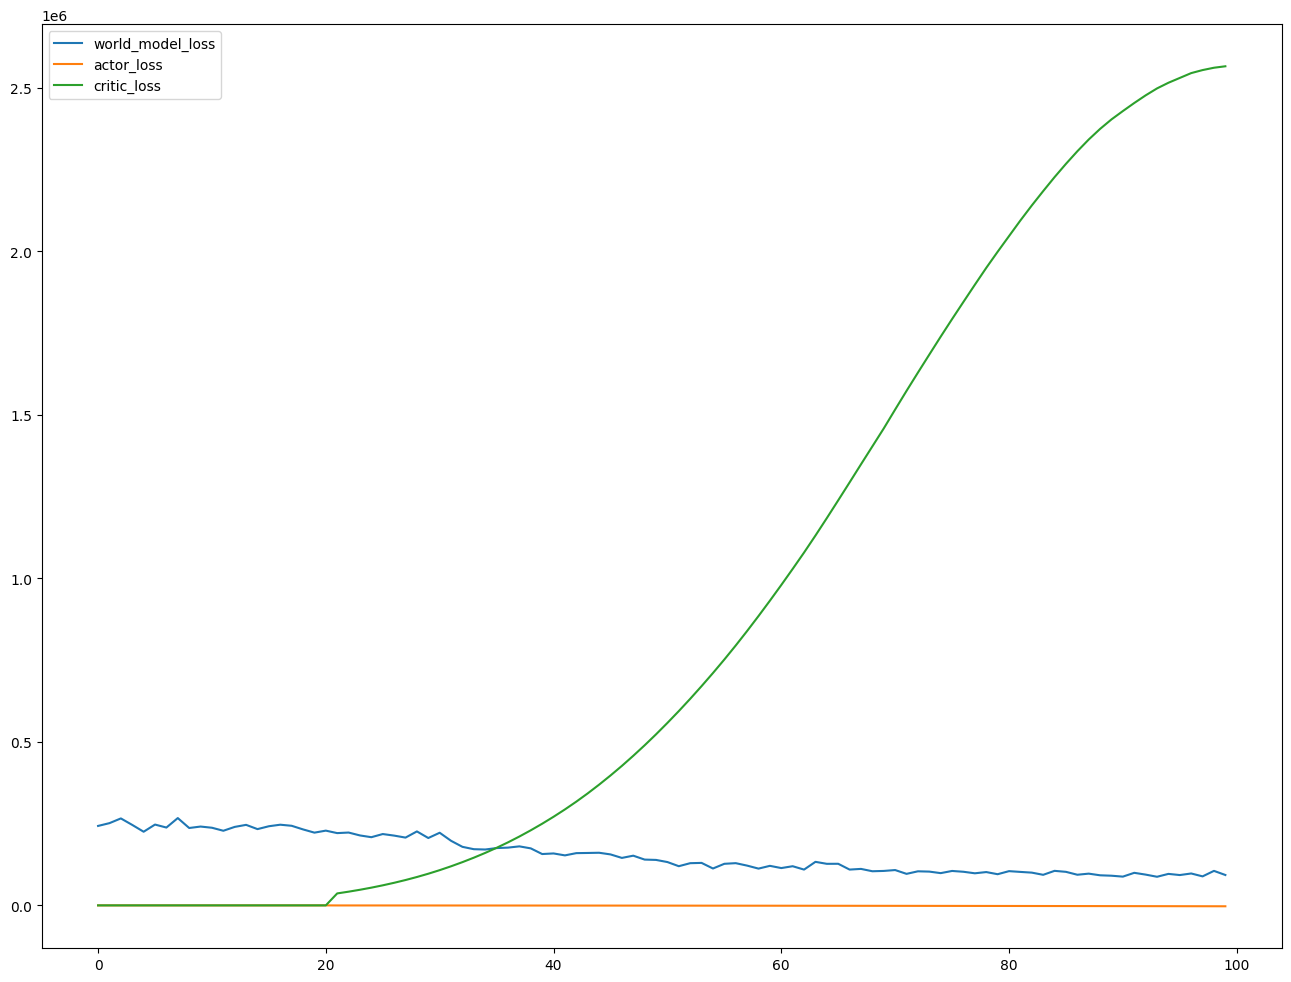

In [ ]:
fig, ax = plt.subplots(figsize=(16, 12))
ax.plot(range(len(loss_history_dict["world_model_loss_history"])),
        loss_history_dict["world_model_loss_history"],
        label="world_model_loss")
ax.plot(range(len(loss_history_dict["actor_loss_history"])),
        loss_history_dict["actor_loss_history"],
        label="actor_loss")
ax.plot(range(len(loss_history_dict["critic_loss_history"])),
        loss_history_dict["critic_loss_history"],
        label="critic_loss")
ax.legend(loc=0)
plt.show()

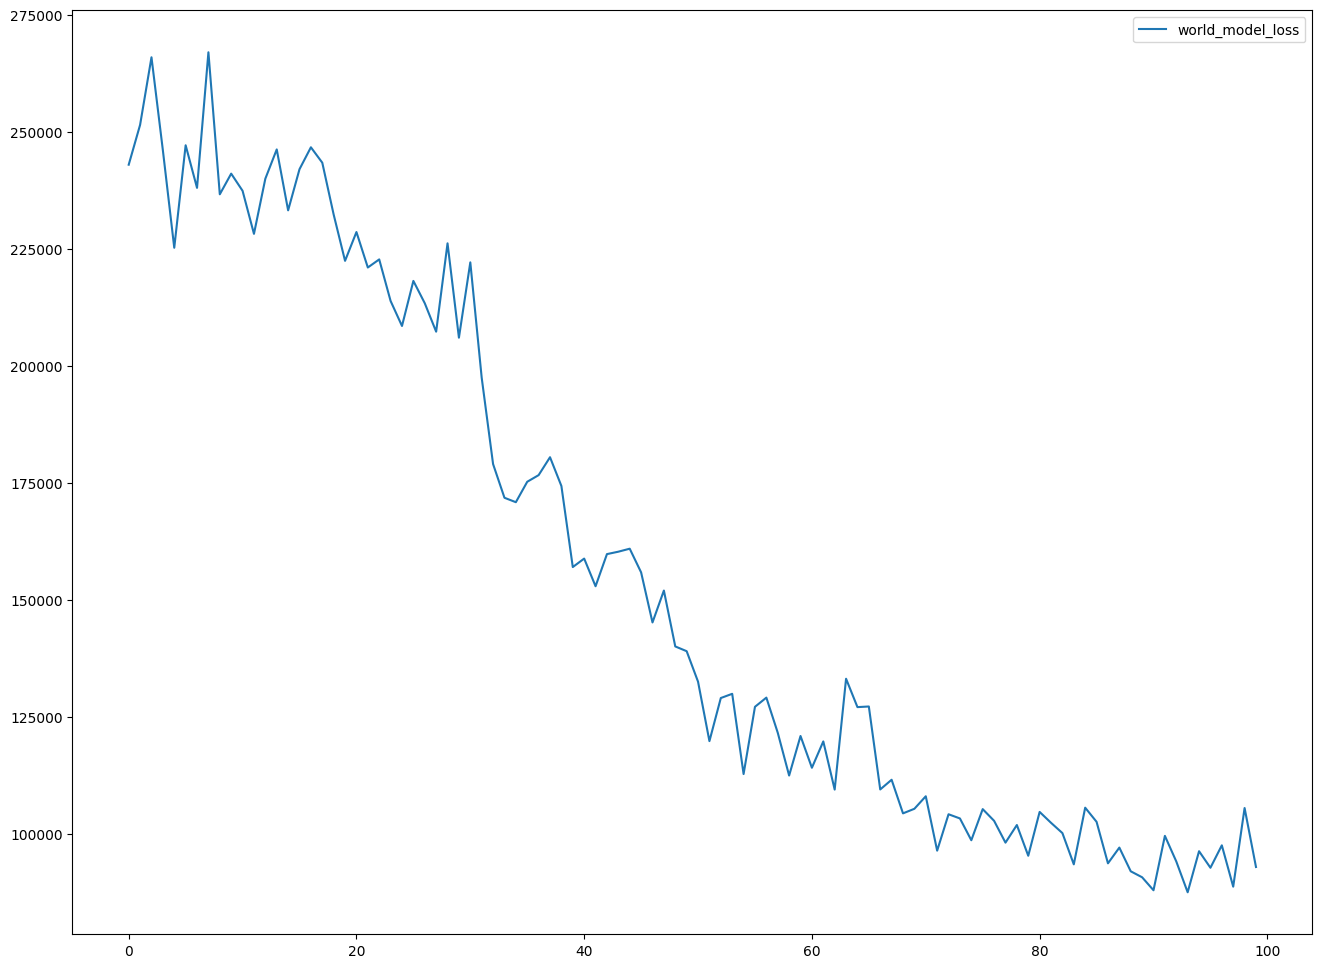

In [ ]:
fig, ax = plt.subplots(figsize=(16, 12))
ax.plot(range(len(loss_history_dict["world_model_loss_history"])),
        loss_history_dict["world_model_loss_history"],
        label="world_model_loss")
ax.legend(loc=0)
plt.show()

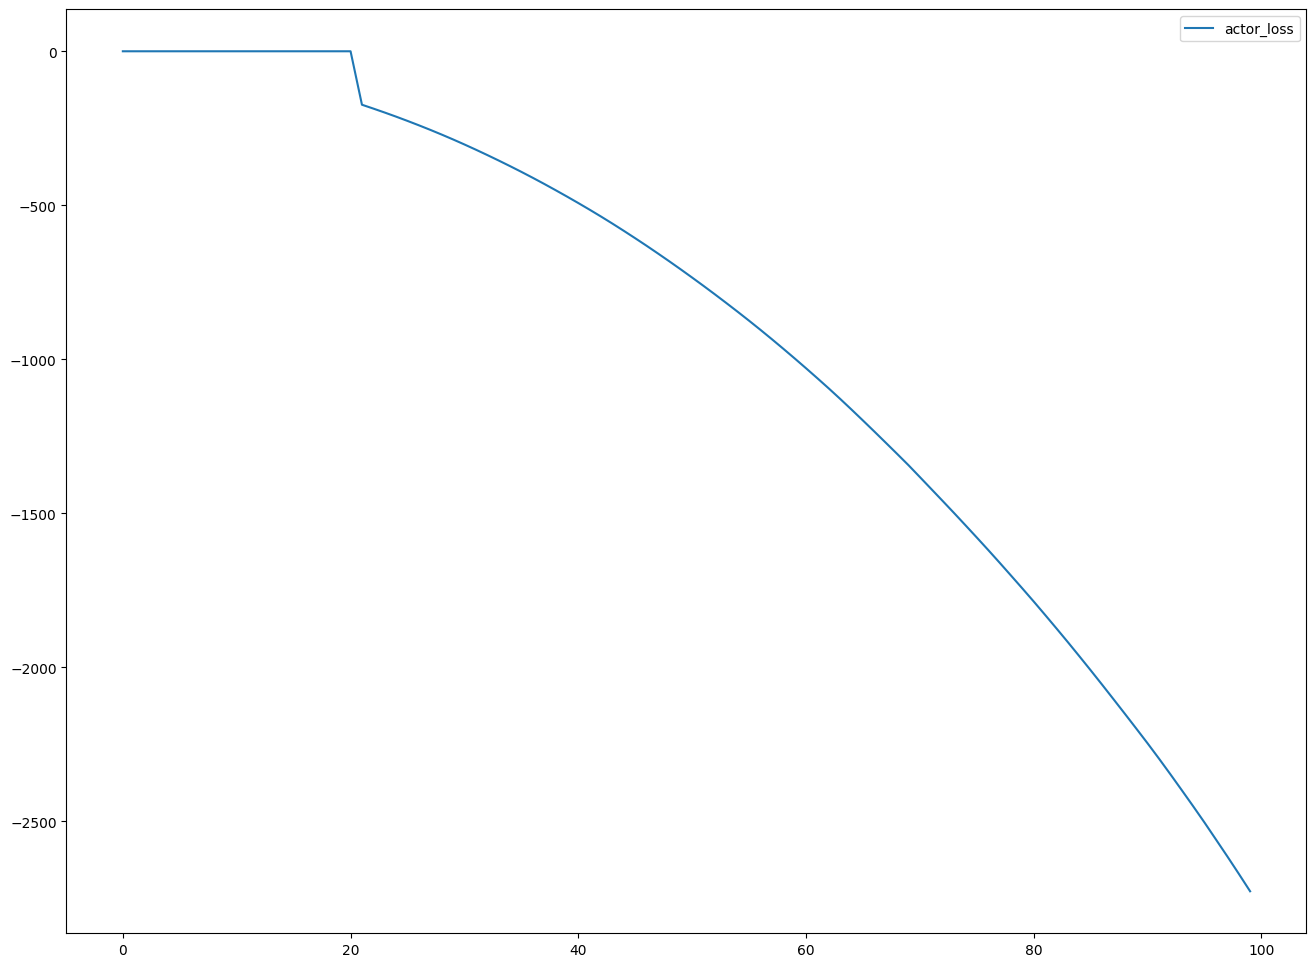

In [ ]:
fig, ax = plt.subplots(figsize=(16, 12))
ax.plot(range(len(loss_history_dict["actor_loss_history"])),
        loss_history_dict["actor_loss_history"],
        label="actor_loss")
ax.legend(loc=0)
plt.show()

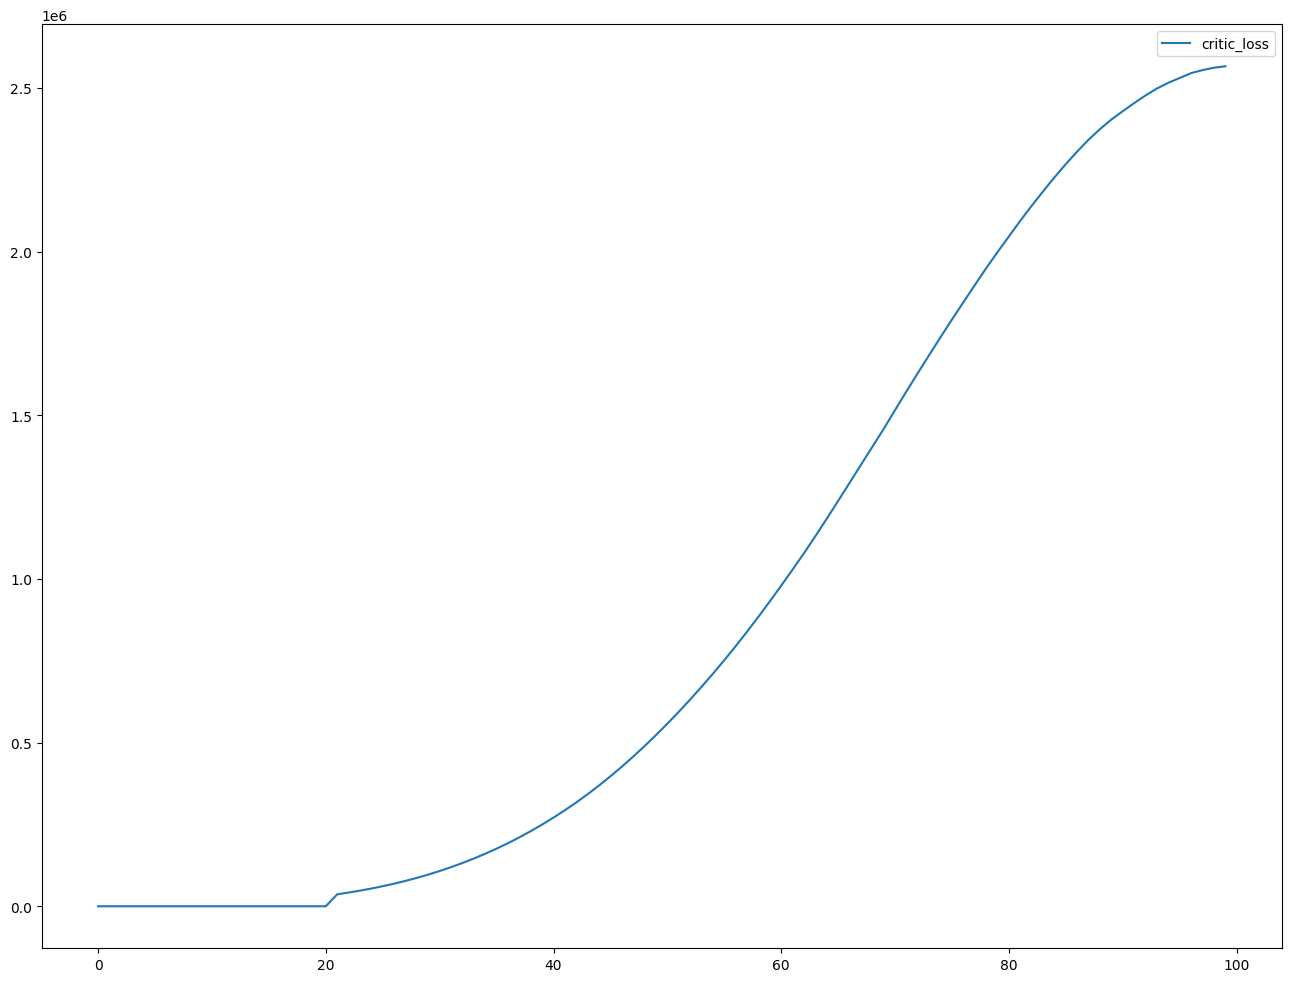

In [ ]:
fig, ax = plt.subplots(figsize=(16, 12))
ax.plot(range(len(loss_history_dict["critic_loss_history"])),
        loss_history_dict["critic_loss_history"],
        label="critic_loss")
ax.legend(loc=0)
plt.show()